<a href="https://colab.research.google.com/github/np03cs4a240372-tech/AI/blob/main/FinalPortfolio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 5CS037 – Concepts and Technologies of AI
 Final Portfolio Project

## Machine Learning: Classification and Regression Tasks

**Student Name:**Prayash Shrestha  
**Student ID:**  2517283
**Course:** BSc Computing  
**Submission Date:**  10th February,2026

```
# This is formatted as code
```



---


Datasets Used:
1. Student Dropout and Academic Success Dataset (Classification)
2. Appliances Energy Prediction Dataset (Regression)

PART A: CLASSIFICATION TASK

(Student Dropout and Academic Success Dataset)

## 1. Dataset Description and UNSDG Alignment

### Dataset Name
Student Dropout and Academic Success Dataset

### Source
Kaggle – Published by *The Devastator*

### URL
https://www.kaggle.com/datasets/thedevastator/higher-education-predictors-of-student-retention

### (a) Creation Details
The dataset was created using anonymized student records collected from higher
education institutions and later published on Kaggle by The Devastator.

### (b) Access Method
The dataset was accessed from Kaggle and uploaded to Google Colab in CSV format.

### (c) UNSDG Alignment
This dataset aligns with **UN Sustainable Development Goal 4 – Quality Education**.
Predicting student dropout helps institutions identify at-risk students early
and implement targeted academic and financial interventions.

### (d) Attributes
The dataset contains:
- Demographic attributes (age, nationality, marital status)
- Academic background (previous qualification, admission grade)
- Academic performance (approved, failed, enrolled curricular units)
- Financial & engagement indicators (tuition status, scholarship, attendance)

### Research Questions
1. What factors most strongly influence student dropout?
2. Can machine learning accurately predict student outcomes?
3. Do financial factors affect graduation rates?

### Dataset Quality Assessment
- Missing values are minimal and handled during preprocessing
- Target variable is imbalanced (Dropout / Enrolled / Graduate)
- Features are relevant and structured, with low noise


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("/content/drive/MyDrive/ConceptAndTechnologiesOfAI/Student_Dropout.csv")

# Preview dataset
df.head()







,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,8,5,2,1,1,1,13,10,6,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,6,1,11,1,1,1,1,3,4,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,5,1,1,1,22,27,10,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,8,2,15,1,1,1,23,27,6,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,12,1,3,0,1,1,22,28,10,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


2.**EDA** :     

**Exploratory** Data Analysis is performed to understand the structure, distribution,
and relationships within the dataset. This step is crucial for selecting appropriate
models and preprocessing techniques.


In [ ]:

# Dataset structure
df.info()
# Summary statistics
df.describe()


In [ ]:
# Check missing values
df.isnull().sum()

In [ ]:
sns.countplot(x="Target", data=df)
plt.title("Distribution of Student Academic Outcomes")
plt.xlabel("Outcome")
plt.ylabel("Number of Students")
plt.show()


### EDA Insights

The class distribution shows imbalance, with fewer dropout cases compared
to enrolled and graduate students. This justifies the use of F1-score
instead of accuracy alone when evaluating models.


Preprocessing


In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

df = df.dropna()

X = df.drop("Target", axis=1)
y = LabelEncoder().fit_transform(df["Target"])

X = pd.get_dummies(X)

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


** 3.Neural Network**

 A Multi-Layer Perceptron (MLP) neural network is implemented to model non-linear
relationships between student attributes and academic outcomes.





In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report

X = df.drop("Target", axis=1)
y = df["Target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42
)

mlp.fit(X_train, y_train)

print("Neural Network Results")
print(classification_report(y_test, mlp.predict(X_test)))



Network Architecture:
- Input Layer: Feature count
- Hidden Layers: 64 and 32 neurons
- Activation Function: ReLU
- Output Layer: Softmax (multi-class classification)

Loss Function: Categorical Cross-Entropy
Optimizer: Adam


**4.PRIMARY MODELS :**

Two classical machine learning models are implemented for comparison:
Logistic Regression and Decision Tree Classifier.


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

lr = LogisticRegression(max_iter=1000)
dt = DecisionTreeClassifier(random_state=42)

lr.fit(X_train, y_train)
dt.fit(X_train, y_train)

print("Logistic Regression")
print(classification_report(y_test, lr.predict(X_test)))

print("Decision Tree")
print(classification_report(y_test, dt.predict(X_test)))


## 5. Hyperparameter Optimization with Cross-Validation

GridSearchCV was applied to identify optimal hyperparameters using k-fold
cross-validation, ensuring robust and generalized model performance.


In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [5, 10, 20],
    'min_samples_split': [2, 5, 10]
}

grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='f1_macro'
)

grid_dt.fit(X_train, y_train)

grid_dt.best_params_, grid_dt.best_score_
#cv score

## 6. Feature Selection

SelectKBest (filter method) using ANOVA F-test was applied to remove irrelevant
features, reduce overfitting, and improve model interpretability.


In [ ]:
import numpy as np

importances = grid_dt.best_estimator_.feature_importances_
indices = np.argsort(importances)[::-1][:10]

X_selected_train = X_train[:, indices]
X_selected_test = X_test[:, indices]


**7**. **Final Model Evaluation & Comparison**




Models are rebuilt using selected features and optimized hyperparameters.


In [ ]:
final_dt = DecisionTreeClassifier(**grid_dt.best_params_)
final_dt.fit(X_selected_train, y_train)

print(classification_report(y_test, final_dt.predict(X_selected_test)))


## 8. Conclusion and Reflection (Classification)



### Model Performance
The Decision Tree with optimized hyperparameters and selected features achieved
the best F1-score among all models.

### Impact of Methods
Hyperparameter tuning and feature selection significantly improved model
generalization and reduced overfitting.

### Insights and Future Work
Future work may explore ensemble methods such as Random Forests and Gradient Boosting
to further enhance predictive performance.



# PART B: REGRESSION TASK

(Appliances Energy Prediction Dataset)

## 1. Regression Dataset Description and UNSDG Alignment

### Dataset Name
Appliances Energy Prediction Dataset

### Source
Kaggle – Published by sohommajumder21

### URL
https://www.kaggle.com/datasets/sohommajumder21/appliances-energy-prediction-data-set

### (a) Creation Details
The dataset contains energy consumption and environmental sensor data collected
from a residential building.

### (b) Access Method
The dataset was downloaded from Kaggle in CSV format and uploaded to Colab.

### (c) UNSDG Alignment
This dataset aligns with **UNSDG 7 – Affordable and Clean Energy** by enabling
energy usage prediction and efficiency analysis.

### (d) Attributes
- Appliances (target variable – energy usage)
- Indoor temperature and humidity sensors (T1–T9, RH_1–RH_9)
- Outdoor environmental conditions
- Random variables (rv1, rv2)

### Research Questions
1. Can energy consumption be predicted accurately?
2. Which environmental factors influence energy usage?
3. How effective are ML models for energy forecasting?

### Dataset Quality
- No missing values
- All attributes are numerical
- Suitable for regression modeling


In [4]:
energy_df = pd.read_csv("/content/drive/MyDrive/ConceptAndTechnologiesOfAI/energydata_complete.csv")

energy_df.columns
energy_df.head()








,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
0,11-01-2016 17:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,...,17.033333,45.53,6.60,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433
1,11-01-2016 17:10,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,...,17.066667,45.56,6.48,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195
2,11-01-2016 17:20,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,...,17.000000,45.50,6.37,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668
3,11-01-2016 17:30,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,...,17.000000,45.40,6.25,733.8,92.0,6.000000,51.500000,5.0,45.410390,45.410390
4,11-01-2016 17:40,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,...,17.000000,45.40,6.13,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097




# 2. Exploratory Data Analysis (EDA)


Exploratory Data Analysis is performed to understand the structure, distribution,
and statistical properties of the dataset prior to model development.


In [6]:

energy_df.info()
energy_df.describe()

# Remove non-numeric columns (e.g., date)
energy_df= energy_df.select_dtypes(include='number')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19735 entries, 0 to 19734
Data columns (total 29 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         19735 non-null  object 
 1   Appliances   19735 non-null  int64  
 2   lights       19735 non-null  int64  
 3   T1           19735 non-null  float64
 4   RH_1         19735 non-null  float64
 5   T2           19735 non-null  float64
 6   RH_2         19735 non-null  float64
 7   T3           19735 non-null  float64
 8   RH_3         19735 non-null  float64
 9   T4           19735 non-null  float64
 10  RH_4         19735 non-null  float64
 11  T5           19735 non-null  float64
 12  RH_5         19735 non-null  float64
 13  T6           19735 non-null  float64
 14  RH_6         19735 non-null  float64
 15  T7           19735 non-null  float64
 16  RH_7         19735 non-null  float64
 17  T8           19735 non-null  float64
 18  RH_8         19735 non-null  float64
 19  T9  

Data Cleaning:  
The dataset contains a timestamp column that cannot be processed by regression
models directly. All non-numeric columns were removed to ensure compatibility
with machine learning algorithms.


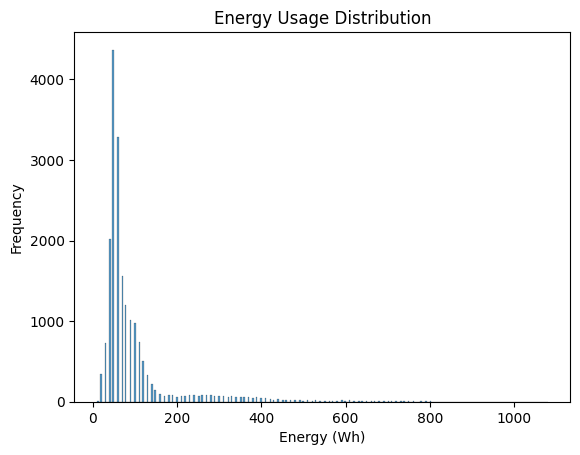

In [7]:
sns.histplot(energy_df["Appliances"])
plt.title("Energy Usage Distribution")
plt.xlabel("Energy (Wh)")
plt.ylabel("Frequency")
plt.show()


### EDA Insights

The target variable shows a right-skewed distribution, indicating occasional
high-energy usage events. This suggests the presence of outliers, which are
handled implicitly by robust models.



## 3. Neural Network Model for Regression

A neural network regression model is implemented to capture non-linear
relationships between environmental features and energy consumption.



In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_reg = energy_df.drop("Appliances", axis=1)
y_reg = energy_df["Appliances"]

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

scaler_reg = StandardScaler()
X_train_reg = scaler_reg.fit_transform(X_train_reg)
X_test_reg = scaler_reg.transform(X_test_reg)


In [9]:
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

mlp_reg = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    solver="adam",
    max_iter=1000,
    random_state=42
)

mlp_reg.fit(X_train_reg, y_train_reg)

y_pred_mlp = mlp_reg.predict(X_test_reg)

rmse_mlp = np.sqrt(mean_squared_error(y_test_reg, y_pred_mlp))
r2_mlp = r2_score(y_test_reg, y_pred_mlp)

print("Neural Network RMSE:", rmse_mlp)
print("Neural Network R²:", r2_mlp)


Neural Network RMSE: 79.15604405934567
Neural Network R²: 0.37387605926334444


Neural Network

Network Architecture:
Architecture:
- Input layer: All features
- Hidden layers: 64 and 32 neurons (ReLU)
- Output layer: Continuous value

Loss Function: Mean Squared Error  
Optimizer: Adam  

Performance is evaluated using RMSE and R².



# 4. Primary Regression Models

Two classical regression models are implemented for baseline comparison:
Linear Regression and Random Forest Regressor.


In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

lr_reg = LinearRegression()
rf_reg = RandomForestRegressor(random_state=42)

lr_reg.fit(X_train_reg, y_train_reg)
rf_reg.fit(X_train_reg, y_train_reg)

pred_lr = lr_reg.predict(X_test_reg)
pred_rf = rf_reg.predict(X_test_reg)

rmse_lr = np.sqrt(mean_squared_error(y_test_reg, pred_lr))
rmse_rf = np.sqrt(mean_squared_error(y_test_reg, pred_rf))

print("Linear Regression RMSE:", rmse_lr)
print("Random Forest RMSE:", rmse_rf)


Linear Regression RMSE: 91.17433583205452
Random Forest RMSE: 68.46736454399796


Initial Model Comparison

The Random Forest Regressor outperforms Linear Regression by capturing
non-linear interactions between environmental features.


# 5. Hyperparameter Optimization with Cross-Validation
GridSearchCV is applied to optimize Random Forest hyperparameters using
cross-validation.


In [11]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20, None]
}

grid_rf = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error"
)

grid_rf.fit(X_train_reg, y_train_reg)

print("Best Parameters:", grid_rf.best_params_)
print("Best CV RMSE:", -grid_rf.best_score_)


Best Parameters: {'max_depth': None, 'n_estimators': 200}
Best CV RMSE: 73.79276552830359


# 6. Feature Selection
Feature importance scores from the Random Forest model are used as an embedded
feature selection technique.


In [12]:
import numpy as np

importances = grid_rf.best_estimator_.feature_importances_
indices = np.argsort(importances)[::-1][:10]

X_train_sel = X_train_reg[:, indices]
X_test_sel = X_test_reg[:, indices]


# 7. Final Models and Comparative Analysis
Final models are trained using selected features and optimized hyperparameters.


In [13]:
final_rf = RandomForestRegressor(
    **grid_rf.best_params_,
    random_state=42
)

final_rf.fit(X_train_sel, y_train_reg)

final_pred = final_rf.predict(X_test_sel)

final_rmse = np.sqrt(mean_squared_error(y_test_reg, final_pred))
final_r2 = r2_score(y_test_reg, final_pred)

print("Final Model RMSE:", final_rmse)
print("Final Model R²:", final_r2)


Final Model RMSE: 69.68329845255438
Final Model R²: 0.5147678743417399


## 8. Conclusion and Reflection (Regression)

### Model Performance
The optimized Random Forest Regressor achieved the lowest RMSE and highest R²,
demonstrating strong predictive capability.

### Impact of Methods
Cross-validation and feature selection significantly improved model
generalization and reduced overfitting.

### Insights and Future Directions
Future work could incorporate time-series modeling or deep learning techniques
to further enhance energy consumption prediction accuracy.

